# Sparse Pixel Image-to-Image CNN

This notebook demonstrates **sparse pixel supervision** for image-to-image tasks using a U-Net-like CNN. This is relevant for federated learning scenarios in remote sensing and climate science.

## Overview
- **Input**: Images with missing/masked pixels (simulating cloud cover, sensor failures)
- **Output**: Pixel-level predictions with sparse supervision (only some pixels have labels)
- **Task**: Image reconstruction/completion from sparse observations
- **Relevance**: Climate monitoring, satellite imagery, federated learning with heterogeneous data

## Masking Strategy
Our sparse pixel approach uses a **dual masking system**:

1. **Input Masking**: Random pixels are set to zero to simulate missing data (e.g., cloud cover, sensor failures). We use ~40% visible pixels to simulate realistic satellite imagery conditions.

2. **Output Masking**: Only a sparse subset (~15%) of output pixels have ground truth labels for supervision. This simulates scenarios where expensive manual labeling is only available for select locations.

**Implementation Details**:
- Input masks are created by randomly selecting pixels with probability `input_sparsity` 
- Output masks are independently created with probability `output_sparsity`
- Loss computation only considers labeled pixels (output mask = 1)
- Model predicts full images but is trained only on sparse supervision

This simulates realistic scenarios where:
- Different clients have different levels of data availability
- Ground truth is only available for sparse pixel locations  
- Sensors have different coverage/reliability patterns

## 1. Setup and Imports

First, let's import the necessary libraries and our custom sparse pixel classes.

In [1]:
# Standard imports
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Optional

# Add the examples directory to path
sys.path.append('../examples')

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# Import our custom classes for sparse pixel tasks
from examples.sparse_pixel_example import SparsePixelDataset, UNetCNN, sparse_pixel_loss

print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print("Imported sparse pixel classes successfully!")

PyTorch version: 2.8.0+cu128
Device available: GPU
Imported sparse pixel classes successfully!


## 2. Configuration and Dataset Creation

Let's configure our sparse pixel experiment with realistic sparsity levels.

In [2]:
# Station density
avg_station_density = 0.09537 # see station vis notebook for details

In [3]:
# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 16
input_sparsity = avg_station_density # 40% of input pixels are visible (rest masked)
output_sparsity = 0.95  # 15% of output pixels have target labels
num_epochs = 5

# Data transforms (keep in [0,1] range for easy visualization)
transform = transforms.Compose([
    transforms.ToTensor(),
])

print(f"Configuration:")
print(f"  Device: {device}")
print(f"  Batch size: {batch_size}")  
print(f"  Input sparsity: {input_sparsity*100}% pixels visible")
print(f"  Output sparsity: {output_sparsity*100}% pixels labeled")
print(f"  Training epochs: {num_epochs}")
print(f"\nThis simulates:")
print(f"  • {100-input_sparsity*100}% of input pixels missing (clouds/sensor failure)")
print(f"  • Only {output_sparsity*100}% of pixels have ground truth labels")

Configuration:
  Device: cuda
  Batch size: 16
  Input sparsity: 9.536999999999999% pixels visible
  Output sparsity: 95.0% pixels labeled
  Training epochs: 5

This simulates:
  • 90.463% of input pixels missing (clouds/sensor failure)
  • Only 95.0% of pixels have ground truth labels


In [4]:
import xarray as xr
from torch.utils.data import Dataset

In [5]:
## APRODITE DATASET
ds_train = xr.open_dataset("/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_TAVE_025deg_V1808.1998.nc").sel(lon=slice(60, 105), lat=slice(20, 40))
ds_test = xr.open_dataset("/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_TAVE_025deg_V1808.1999.nc").sel(lon=slice(60, 105), lat=slice(20, 40))

In [6]:
# add lat/lon channels 
ds_train["lats"] = (("time", "lat", "lon",),  np.tile(ds_train.lat.values, (ds_train.time.size, ds_train.lon.size, 1)).transpose(0,2,1))
ds_train["lons"] = (("time", "lat", "lon",),  np.tile(ds_train.lon.values, (ds_train.time.size, ds_train.lat.size, 1)))
ds_test["lats"] = (("time", "lat", "lon",),  np.tile(ds_train.lat.values, (ds_train.time.size, ds_train.lon.size, 1)).transpose(0,2,1))
ds_test["lons"] = (("time", "lat", "lon",),  np.tile(ds_train.lon.values, (ds_train.time.size, ds_train.lat.size, 1)))

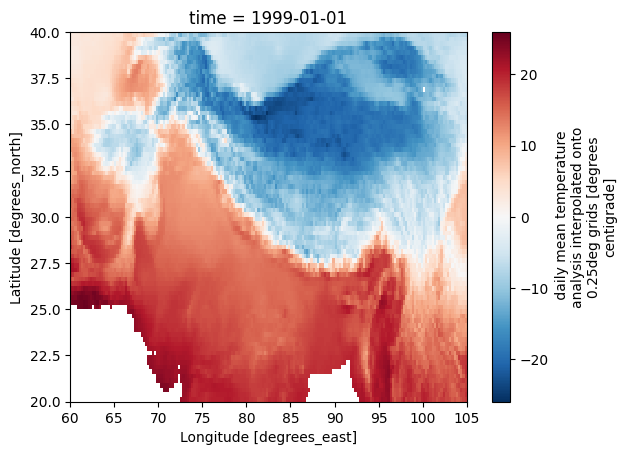

In [15]:
ds_test.tave[0].plot()

In [27]:
np.max(ds_train.tave.values), np.min(ds_train.tave.values)

(np.float32(nan), np.float32(nan))

In [17]:
da_train = ds_train[["tave", "lats", "lons"]].to_array()
da_test = ds_test[["tave", "lats", "lons"]].to_array()

In [36]:
# remove nan values
da_train = da_train.fillna(0)
da_test = da_test.fillna(0)

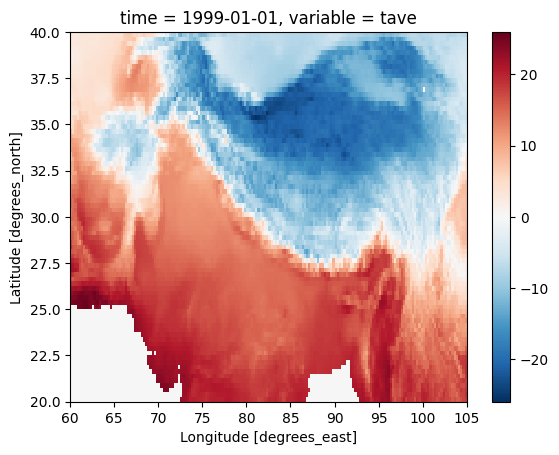

In [40]:
da_test.sel(variable="tave").isel(time=0).plot()

In [44]:
class StationPatchDataset(Dataset):
    """
    PyTorch Dataset that extracts 32x32 spatial patches
    from an xarray DataArray with dimensions (time, lat, lon) 
    using the station mask.
    """

    def __init__(
        self,
        dataarray: xr.DataArray,
        patch_size: int = 32,
        stride: int = 32,
        normalize: bool = True,
        dtype: torch.dtype = torch.float32,
        input_sparsity: float = None,
        output_sparsity: float = 0.1, 
        transform=None,
    ):
        """
        Parameters
        ----------
        dataarray : xr.DataArray
            Shape: (time, lat, lon)
        patch_size : int
            Spatial patch size (default 32)
        stride : int
            Sliding window stride (default 32, non-overlapping)
        normalize : bool
            Whether to normalize data (mean/std over full array)
        dtype : torch.dtype
            Torch dtype
        """

        assert set(dataarray.dims) == {"variable", "time", "lat", "lon"}, \
            "DataArray must have dims ('variable', 'time', 'lat', 'lon')"

        self.da = dataarray
        self.patch_size = patch_size
        self.stride = stride
        self.dtype = dtype

        # Convert to numpy (lazy-safe)
        self.data = self.da.values.astype(np.float32) # shape (channel, time, lon, lat,)

        if normalize:
            self.mean = np.nanmean(self.data, axis=(1, 2, 3), keepdims=True)
            self.std = np.nanstd(self.data, axis=(1, 2, 3), keepdims=True) + 1e-6
            self.data = (self.data - self.mean) / self.std

        self.channels, self.time_len, self.lat_len, self.lon_len = self.data.shape

        # Precompute all patch indices
        self.indices = []
        for t in range(self.time_len):
            for i in range(0, self.lat_len - patch_size + 1, stride):
                for j in range(0, self.lon_len - patch_size + 1, stride):
                    self.indices.append((t, i, j))

        if input_sparsity is None:
            self.station_mask = np.load("station_data/hma_station_mask.npy") # shape (lat, lon)
        else:
            self.input_sparsity = input_sparsity
        self.output_sparsity = output_sparsity

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        t, i, j = self.indices[idx]

        patch = self.data[:,
            t,
            i : i + self.patch_size,
            j : j + self.patch_size,
        ]

        # Convert to torch tensor
        # Shape: [3, 32, 32] (channel-first)
        patch = torch.tensor(patch, dtype=self.dtype) #.unsqueeze(0)
        np.random.seed(idx)  # For reproducible masks per sample

        if hasattr(self, "input_sparsity"):
            # Create input mask: which pixels are visible in the input
            input_mask = torch.rand(patch.shape[-2], patch.shape[-1]) < self.input_sparsity

        else:
            input_mask = self.station_mask[i : i + self.patch_size,
                                 j : j + self.patch_size]
            input_mask = torch.tensor(input_mask, dtype=torch.bool)
        
        # Output mask: which pixels have target labels  
        output_mask = torch.rand(patch.shape[-2], patch.shape[-1]) < self.output_sparsity
        
        # Create sparse input (mask out some pixels)
        sparse_input = patch.clone()
        sparse_input[0, ~input_mask] = 0.0  # Set masked pixels to 0
        
        # Create sparse target (only some pixels have labels)
        sparse_target = patch[0].clone().unsqueeze(0)  # Shape [1, 32, 32]
        sparse_target[0, ~output_mask] = -1.0  # Mark unlabeled pixels as -1
        
        return sparse_input, sparse_target, input_mask.float(), output_mask.float()

In [45]:
# Create sparse pixel datasets
print("Creating sparse pixel datasets...")

train_dataset = StationPatchDataset(
    dataarray=da_train,
    output_sparsity=output_sparsity,
    transform=transform,
)

test_dataset = StationPatchDataset(
    dataarray=da_test,
    output_sparsity=output_sparsity,
    transform=transform, 
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataset sizes:")
print(f"  Training: {len(train_dataset)} samples")
print(f"  Test: {len(test_dataset)} samples")
print(f"  Avg labeled pixels per image: ~{int(32*32*output_sparsity)} out of {32*32}")
print(f"  Avg visible input pixels per image: ~{int(32*32*input_sparsity)} out of {32*32}")

Creating sparse pixel datasets...

Dataset sizes:
  Training: 3650 samples
  Test: 3650 samples
  Avg labeled pixels per image: ~972 out of 1024
  Avg visible input pixels per image: ~97 out of 1024


In [23]:
print(train_dataset.data.shape)
print(train_dataset.station_mask.shape)


(3, 365, 80, 180)
(80, 180)


## 3. Data Visualization

Let's visualize the sparse pixel setup - input images with missing pixels and target images with sparse labels.

Visualizing sparse pixel data structure...
Debug sample 0: inp_mask shape=(32, 32), dtype=bool
Debug sample 0: out_mask shape=(32, 32), dtype=bool
Debug sample 1: inp_mask shape=(32, 32), dtype=bool
Debug sample 1: out_mask shape=(32, 32), dtype=bool
Debug sample 2: inp_mask shape=(32, 32), dtype=bool
Debug sample 2: out_mask shape=(32, 32), dtype=bool
Debug sample 3: inp_mask shape=(32, 32), dtype=bool
Debug sample 3: out_mask shape=(32, 32), dtype=bool


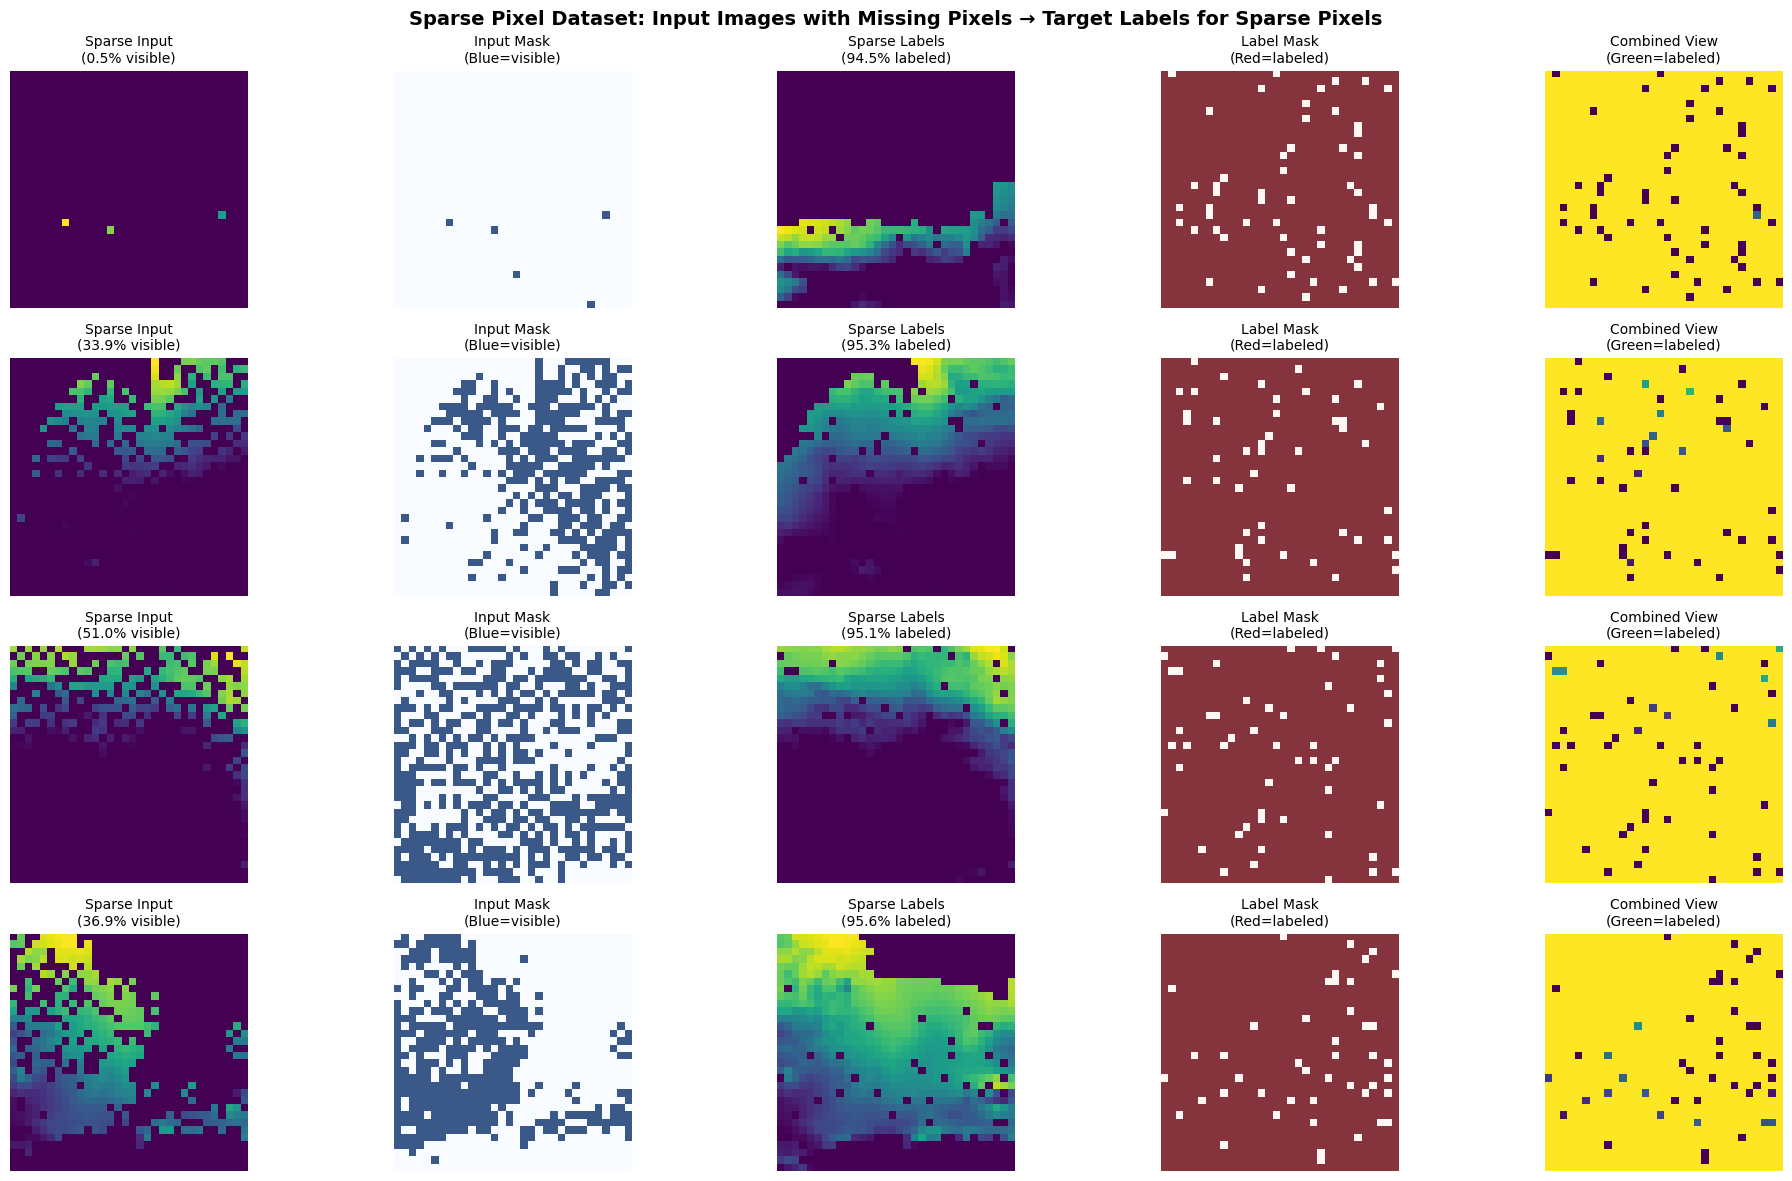

In [46]:
def visualize_sparse_pixel_data(dataset, num_samples=6):
    """Visualize sparse pixel input/output pairs."""
    
    fig, axes = plt.subplots(num_samples, 5, figsize=(20, num_samples*3))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        sparse_input, sparse_target, input_mask, output_mask = dataset[i]
        
        # Convert to numpy for visualization and ensure correct types
        sparse_inp = sparse_input[0].numpy() #.permute(1, 2, 0).numpy()
        sparse_tgt = sparse_target[0].numpy() #.permute(1, 2, 0).numpy()
        inp_mask = input_mask.numpy().astype(bool)  # Ensure boolean type
        out_mask = output_mask.numpy().astype(bool)  # Ensure boolean type
        
        print(f"Debug sample {i}: inp_mask shape={inp_mask.shape}, dtype={inp_mask.dtype}")
        print(f"Debug sample {i}: out_mask shape={out_mask.shape}, dtype={out_mask.dtype}")
        
        # Original target (for comparison)
        original_target = sparse_tgt.copy()
        original_target[sparse_tgt == -1] = 0  # Replace -1 with 0 for visualization
        
        # 1. Sparse input (with missing pixels)
        axes[i, 0].imshow(np.clip(sparse_inp, 0, 1))
        axes[i, 0].set_title(f'Sparse Input\n({inp_mask.mean()*100:.1f}% visible)', fontsize=10)
        axes[i, 0].axis('off')
        
        # 2. Input mask
        axes[i, 1].imshow(inp_mask, cmap='Blues', alpha=0.8)
        axes[i, 1].set_title('Input Mask\n(Blue=visible)', fontsize=10)
        axes[i, 1].axis('off')
        
        # 3. Sparse target labels
        axes[i, 2].imshow(np.clip(original_target, 0, 1))
        axes[i, 2].set_title(f'Sparse Labels\n({out_mask.mean()*100:.1f}% labeled)', fontsize=10)
        axes[i, 2].axis('off')
        
        # 4. Output mask
        axes[i, 3].imshow(out_mask, cmap='Reds', alpha=0.8)
        axes[i, 3].set_title('Label Mask\n(Red=labeled)', fontsize=10)
        axes[i, 3].axis('off')
        
        # 5. Combined visualization - simplified approach
        combined = sparse_inp.copy()  # Start with sparse input
        
        # Create overlay for labeled pixels (make them more visible)
        if out_mask.any():
            overlay = np.zeros_like(sparse_inp)
            overlay[out_mask] = 99  # Green overlay for labeled pixels
            combined = np.clip(combined + overlay, 0, 1)
        
        axes[i, 4].imshow(np.clip(combined, 0, 1))
        axes[i, 4].set_title('Combined View\n(Green=labeled)', fontsize=10)
        axes[i, 4].axis('off')
    
    plt.suptitle('Sparse Pixel Dataset: Input Images with Missing Pixels → Target Labels for Sparse Pixels', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize the dataset
print("Visualizing sparse pixel data structure...")
visualize_sparse_pixel_data(train_dataset, num_samples=4)

## 4. Model Creation and Architecture

Let's create our U-Net CNN and examine its architecture.

In [47]:
# Create U-Net model for pixel-to-pixel prediction
model = UNetCNN(in_channels=3, out_channels=1, base_filters=32).to(device)

# Print model architecture summary
print("U-Net CNN Architecture:")
print("=" * 50)
print(model)
print("=" * 50)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size (MB): {total_params * 4 / (1024**2):.2f}")
print(f"\nArchitecture: U-Net with skip connections")
print(f"  • Encoder: 3 downsampling layers")
print(f"  • Bottleneck: Deep feature extraction")
print(f"  • Decoder: 3 upsampling layers with skip connections")
print(f"  • Output: Sigmoid activation for [0,1] pixel values")

U-Net CNN Architecture:
UNetCNN(
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1,

## 5. Training Loop

Now let's train our model using sparse pixel supervision.

In [48]:
# Training setup for sparse pixel image-to-image task
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track training progress
train_losses = []
train_mse_values = []
total_labeled_pixels_per_epoch = []

print("Starting sparse pixel training...")
print("=" * 60)

model.train()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    epoch_mse = 0.0
    epoch_labeled_pixels = 0
    batch_count = 0
    
    for batch_idx, (sparse_inputs, sparse_targets, input_masks, output_masks) in enumerate(train_loader):
        # Move to device
        sparse_inputs = sparse_inputs.to(device)
        sparse_targets = sparse_targets.to(device)
        input_masks = input_masks.to(device)
        output_masks = output_masks.to(device)
        #print(f"Debug batch {batch_idx}: sparse_inputs shape={sparse_inputs.shape}, dtype={sparse_inputs.dtype}")
        #print(f"Debug batch {batch_idx}: sparse_targets shape={sparse_targets.shape}, dtype={sparse_targets.dtype}") 
        #print(f"Debug batch {batch_idx}: output_masks shape={output_masks.shape}, dtype={output_masks.dtype}")
        #print(f"Debug batch {batch_idx}: input_masks shape={input_masks.shape}, dtype={input_masks.dtype}")   
        
        # Forward pass - predict full images
        optimizer.zero_grad()
        predicted_images = model(sparse_inputs)
        #print(predicted_images.shape)
        
        # Calculate sparse pixel loss (only on labeled pixels)
        loss = sparse_pixel_loss(predicted_images, sparse_targets, output_masks)
        
        if loss is not None:  # Only if there are labeled pixels in the batch
            loss.backward()
            optimizer.step()
            
            # Track statistics
            epoch_loss += loss.item()
            batch_count += 1
            
            # Calculate MSE on labeled pixels (better metric for regression)
            with torch.no_grad():
                # Convert to [0,1] range for comparison
                pred_clamped = torch.clamp(predicted_images, 0, 1)
                target_clamped = torch.clamp(sparse_targets, 0, 1)
                
                # Calculate MSE per pixel on labeled pixels only
                pixel_mse = F.mse_loss(pred_clamped, target_clamped, reduction='none')
                pixel_mse_mean = pixel_mse.mean(dim=1)  # Average over color channels
                
                # Only consider labeled pixels for MSE calculation
                labeled_pixel_mse = pixel_mse_mean[output_masks.bool()].mean()
                if not torch.isnan(labeled_pixel_mse):
                    epoch_mse += labeled_pixel_mse.item()
                
                epoch_labeled_pixels += output_masks.sum().item()
            
            # Print progress every 500 batches (less verbose)
            if batch_idx % 500 == 0:
                labeled_pixels_in_batch = int(output_masks.sum().item())
                print(f'  Epoch {epoch+1}, Batch {batch_idx:4d}: Loss={loss.item():.4f}, '
                      f'Labeled pixels={labeled_pixels_in_batch:4d}')
    
    # Calculate epoch metrics
    if batch_count > 0:
        avg_loss = epoch_loss / batch_count
        avg_mse = epoch_mse / batch_count
    else:
        avg_loss = 0.0
        avg_mse = 0.0
    
    train_losses.append(avg_loss)
    train_mse_values.append(avg_mse)
    total_labeled_pixels_per_epoch.append(epoch_labeled_pixels)
    
    print(f"\nEpoch {epoch+1}/{num_epochs} Completed:")
    print(f"  Average Loss: {avg_loss:.4f}")
    print(f"  Average MSE: {avg_mse:.6f}")
    print(f"  RMSE: {np.sqrt(avg_mse):.6f}")
    print(f"  Labeled pixels processed: {int(epoch_labeled_pixels):,}")
    print(f"  Batches processed: {batch_count}/{len(train_loader)}")
    print("-" * 50)

print("\nTraining completed!")
print(f"Final MSE: {train_mse_values[-1]:.6f}")
print(f"Final RMSE: {np.sqrt(train_mse_values[-1]):.6f}")
print("This simulates federated learning with sparse pixel supervision!")

Starting sparse pixel training...
  Epoch 1, Batch    0: Loss=0.8241, Labeled pixels=15582

Epoch 1/5 Completed:
  Average Loss: 0.6483
  Average MSE: 0.047317
  RMSE: 0.217525
  Labeled pixels processed: 3,550,828
  Batches processed: 229/229
--------------------------------------------------
  Epoch 2, Batch    0: Loss=0.5535, Labeled pixels=15541

Epoch 2/5 Completed:
  Average Loss: 0.5426
  Average MSE: 0.017520
  RMSE: 0.132364
  Labeled pixels processed: 3,550,482
  Batches processed: 229/229
--------------------------------------------------
  Epoch 3, Batch    0: Loss=0.2424, Labeled pixels=15607

Epoch 3/5 Completed:
  Average Loss: 0.5363
  Average MSE: 0.015758
  RMSE: 0.125530
  Labeled pixels processed: 3,550,351
  Batches processed: 229/229
--------------------------------------------------
  Epoch 4, Batch    0: Loss=0.5163, Labeled pixels=15566

Epoch 4/5 Completed:
  Average Loss: 0.5245
  Average MSE: 0.008994
  RMSE: 0.094835
  Labeled pixels processed: 3,550,651
  

## 6. Training Visualization

Let's visualize the training progress.

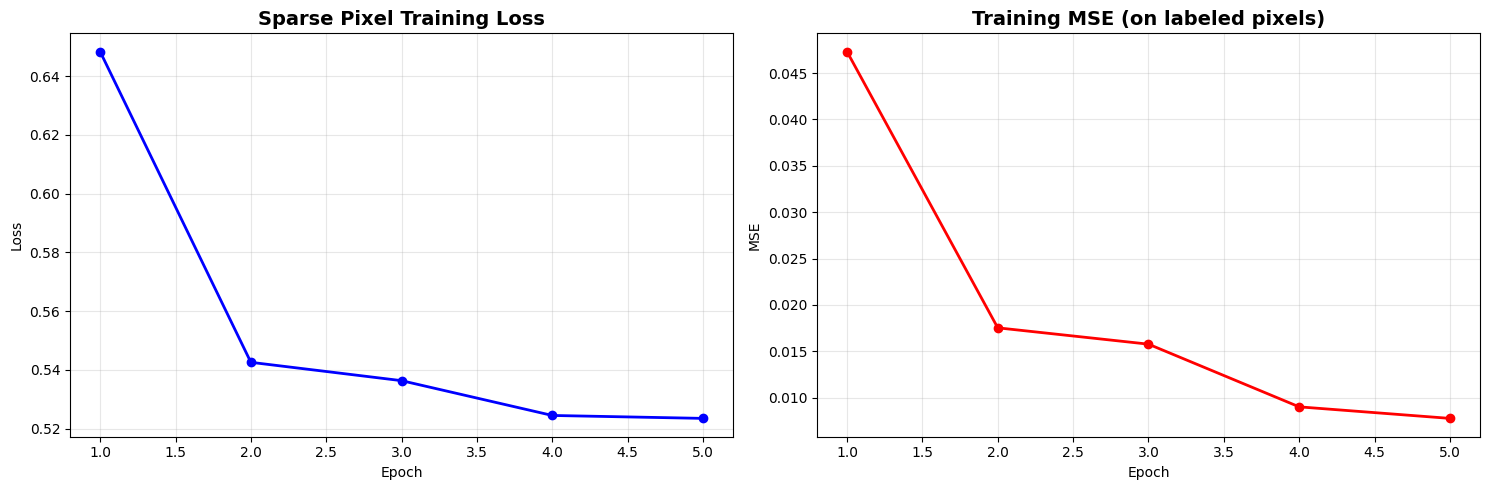


Final Sparse Pixel Training Statistics:
  Final Loss: 0.5235
  Final MSE: 0.007748
  Final RMSE: 0.088025
  Total labeled pixels processed in last epoch: 3,550,873
  Training completed for 5 epochs


In [49]:
# Plot training curves for sparse pixel training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Check if we have training data to plot
if len(train_losses) > 0 and len(train_mse_values) > 0:
    # Loss curve
    epochs = range(1, len(train_losses) + 1)
    ax1.plot(epochs, train_losses, 'b-o', linewidth=2, markersize=6)
    ax1.set_title('Sparse Pixel Training Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)

    # MSE curve (better metric for regression)
    ax2.plot(epochs, train_mse_values, 'r-o', linewidth=2, markersize=6)
    ax2.set_title('Training MSE (on labeled pixels)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print final training stats
    print(f"\nFinal Sparse Pixel Training Statistics:")
    print(f"  Final Loss: {train_losses[-1]:.4f}")
    print(f"  Final MSE: {train_mse_values[-1]:.6f}")
    print(f"  Final RMSE: {np.sqrt(train_mse_values[-1]):.6f}")
    print(f"  Total labeled pixels processed in last epoch: {int(total_labeled_pixels_per_epoch[-1]):,}")
    print(f"  Training completed for {len(train_losses)} epochs")
else:
    print("⚠️  No training data available to plot.")
    print("   Please run the training cell first to generate the training curves.")
    print(f"   Current state: train_losses has {len(train_losses)} values")
    print(f"                 train_mse_values has {len(train_mse_values)} values")

## 7. Model Evaluation

Now let's evaluate our trained model on the full test set.

In [50]:
# Evaluate the trained model on test set
print("Evaluating sparse pixel model on test set...")

model.eval()
test_losses = []
test_mse_values = []
pixel_mse_values = []
total_labeled_test_pixels = 0
total_test_pixels = 0

with torch.no_grad():
    for sparse_inputs, sparse_targets, input_masks, output_masks in test_loader:
        # Move to device
        sparse_inputs = sparse_inputs.to(device)
        sparse_targets = sparse_targets.to(device)
        input_masks = input_masks.to(device)
        output_masks = output_masks.to(device)
        
        # Forward pass
        predicted_images = model(sparse_inputs)
        
        # Calculate loss only on labeled pixels
        loss = sparse_pixel_loss(predicted_images, sparse_targets, output_masks)
        if loss is not None:
            test_losses.append(loss.item())
        
        # Calculate MSE for labeled pixels
        pred_clamped = torch.clamp(predicted_images, 0, 1)
        target_clamped = torch.clamp(sparse_targets, 0, 1)
        
        # Iterate through batch to handle boolean indexing correctly
        for b in range(pred_clamped.shape[0]):
            # Get the mask for this image
            item_mask = output_masks[b].bool()
            
            if item_mask.sum() > 0:  # If there are labeled pixels
                # Get MSE for labeled pixels only
                item_mse = F.mse_loss(pred_clamped[b], target_clamped[b], reduction='none')
                item_mse = item_mse.mean(dim=0)  # Average over color channels
                
                # Extract MSE values for labeled pixels
                labeled_mse_values = item_mse[item_mask]
                pixel_mse_values.extend(labeled_mse_values.cpu().numpy())
                
                # Calculate batch-level MSE
                batch_mse = labeled_mse_values.mean().item()
                test_mse_values.append(batch_mse)
                
                total_labeled_test_pixels += item_mask.sum().item()
                total_test_pixels += item_mask.numel()

# Calculate final metrics
avg_test_loss = np.mean(test_losses) if len(test_losses) > 0 else 0.0
avg_test_mse = np.mean(test_mse_values) if len(test_mse_values) > 0 else 0.0
avg_pixel_mse = np.mean(pixel_mse_values) if len(pixel_mse_values) > 0 else 0.0
test_rmse = np.sqrt(avg_test_mse) if avg_test_mse > 0 else 0.0
test_sparsity = total_labeled_test_pixels / max(1, total_test_pixels)

# Calculate PSNR (Peak Signal-to-Noise Ratio) - common image quality metric
# PSNR = 20 * log10(MAX_I) - 10 * log10(MSE)
# For images normalized to [0,1], MAX_I = 1
test_psnr = 20 * np.log10(1.0) - 10 * np.log10(avg_pixel_mse) if avg_pixel_mse > 0 else float('inf')

# Print clean, formatted results
print("\nTest Set Evaluation Results:")
print("=" * 50)
print(f"Test Loss (labeled pixels): {avg_test_loss:.4f}")
print(f"Test MSE: {avg_test_mse:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")
print(f"Test PSNR: {test_psnr:.2f} dB")
print(f"Test Sparsity: {test_sparsity*100:.1f}% labeled")
print(f"Total Test Batches: {len(test_loader)}")

if len(pixel_mse_values) > 0:
    print(f"\nPixel-level MSE Statistics:")
    print(f"  Min MSE: {min(pixel_mse_values):.6f}")
    print(f"  Max MSE: {max(pixel_mse_values):.6f}")
    print(f"  Median MSE: {np.median(pixel_mse_values):.6f}")
    print(f"  Standard Deviation: {np.std(pixel_mse_values):.6f}")

print(f"\nEvaluation complete - regression quality metrics")
print(f"for sparse supervision federated learning scenario.")
print(f"PSNR > 30 dB is generally considered good image quality.")

Evaluating sparse pixel model on test set...

Test Set Evaluation Results:
Test Loss (labeled pixels): 0.5213
Test MSE: 0.004436
Test RMSE: 0.066604
Test PSNR: 23.53 dB
Test Sparsity: 95.0% labeled
Total Test Batches: 229

Pixel-level MSE Statistics:
  Min MSE: 0.000000
  Max MSE: 0.999958
  Median MSE: 0.000005
  Standard Deviation: 0.022790

Evaluation complete - regression quality metrics
for sparse supervision federated learning scenario.
PSNR > 30 dB is generally considered good image quality.


## 8. Results Visualization

Let's create comprehensive visualizations of our training results.

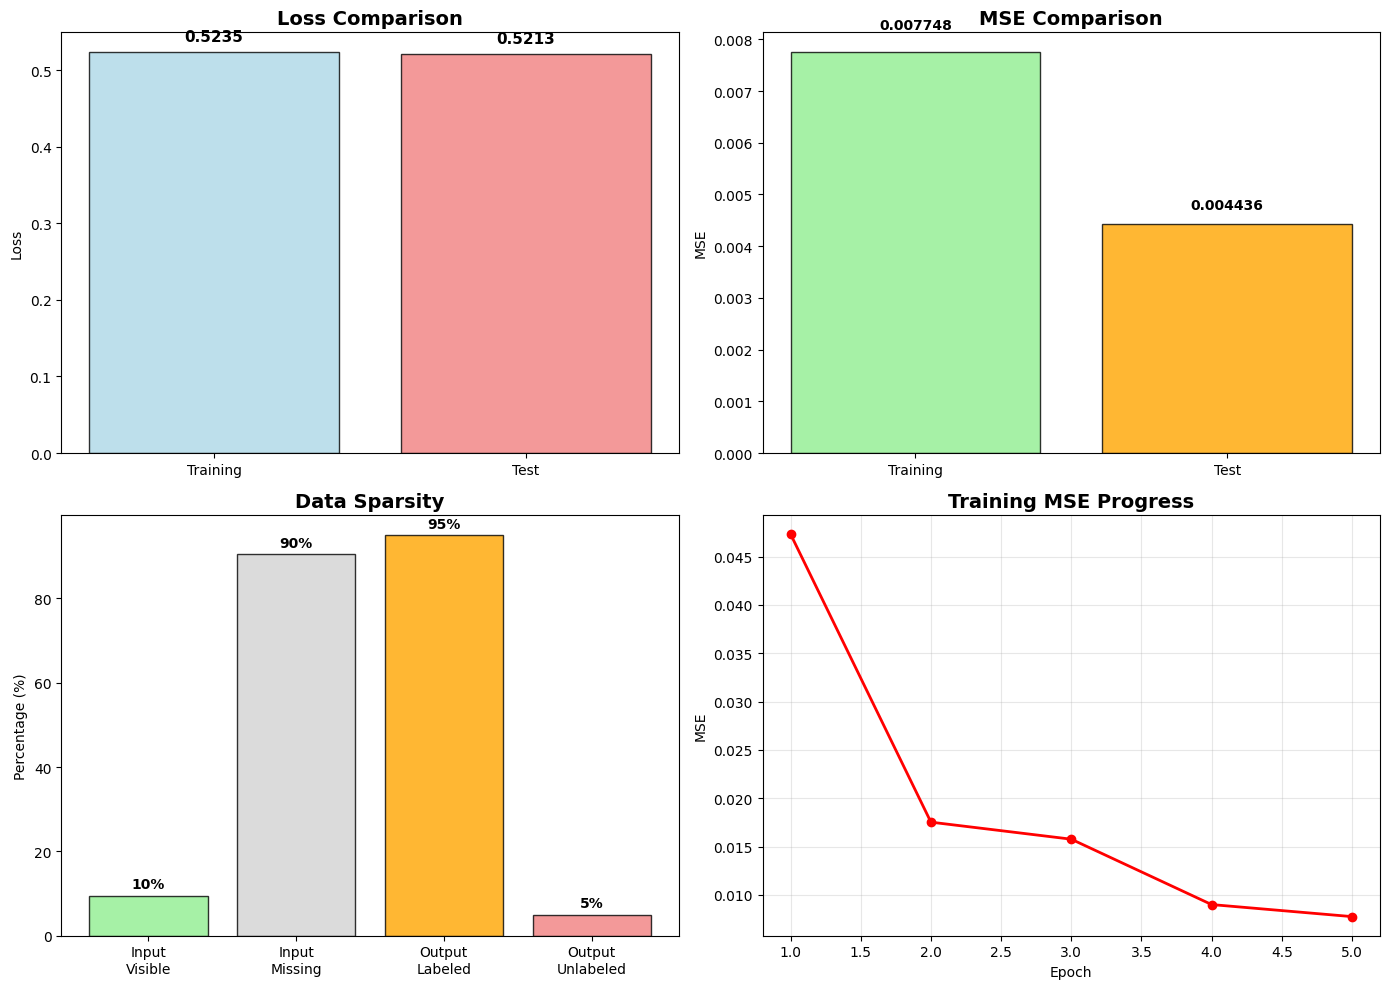


Sparse Pixel Training Results:
Final Training Loss: 0.5235
Final Test Loss: 0.5213
Training MSE: 0.007748
Training RMSE: 0.088025
Test MSE: 0.004436
Test RMSE: 0.066604
Test PSNR: 23.53 dB
Model Parameters: 1,928,417


In [51]:
# Create simple results visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training vs Test Loss
if len(train_losses) > 0 and 'avg_test_loss' in globals():
    metrics = ['Training', 'Test']
    loss_values = [train_losses[-1], avg_test_loss]
    colors = ['lightblue', 'lightcoral']

    bars = ax1.bar(metrics, loss_values, color=colors, edgecolor='black', alpha=0.8)
    ax1.set_title('Loss Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Loss')

    for bar, value in zip(bars, loss_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
                 f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Training vs Test MSE (better metric for regression)
if len(train_mse_values) > 0 and 'avg_test_mse' in globals():
    metrics = ['Training', 'Test']
    mse_values = [train_mse_values[-1], avg_test_mse]
    colors = ['lightgreen', 'orange']

    bars = ax2.bar(metrics, mse_values, color=colors, edgecolor='black', alpha=0.8)
    ax2.set_title('MSE Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('MSE')

    for bar, value in zip(bars, mse_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                 f'{value:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Data Sparsity
categories = ['Input\nVisible', 'Input\nMissing', 'Output\nLabeled', 'Output\nUnlabeled']
sparsity_values = [
    input_sparsity * 100,
    (1 - input_sparsity) * 100,
    output_sparsity * 100,
    (1 - output_sparsity) * 100
]
colors = ['lightgreen', 'lightgray', 'orange', 'lightcoral']

bars = ax3.bar(categories, sparsity_values, color=colors, alpha=0.8, edgecolor='black')
ax3.set_title('Data Sparsity', fontsize=14, fontweight='bold')
ax3.set_ylabel('Percentage (%)')

for bar, value in zip(bars, sparsity_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{value:.0f}%', ha='center', va='bottom', fontweight='bold')

# 4. Training Progress (MSE over epochs)
if len(train_mse_values) > 0:
    epochs = range(1, len(train_mse_values) + 1)
    ax4.plot(epochs, train_mse_values, 'o-', linewidth=2, markersize=6, color='red')
    ax4.set_title('Training MSE Progress', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('MSE')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSparse Pixel Training Results:")
print("=" * 40)
if len(train_losses) > 0:
    print(f"Final Training Loss: {train_losses[-1]:.4f}")
if 'avg_test_loss' in globals():
    print(f"Final Test Loss: {avg_test_loss:.4f}")
if len(train_mse_values) > 0:
    print(f"Training MSE: {train_mse_values[-1]:.6f}")
    print(f"Training RMSE: {np.sqrt(train_mse_values[-1]):.6f}")
if 'avg_test_mse' in globals():
    print(f"Test MSE: {avg_test_mse:.6f}")
    print(f"Test RMSE: {np.sqrt(avg_test_mse):.6f}")
if 'test_psnr' in globals():
    print(f"Test PSNR: {test_psnr:.2f} dB")
print(f"Model Parameters: {total_params:,}")
print("=" * 40)

## 9. Sample Predictions

Let's visualize some sample predictions from our trained model.

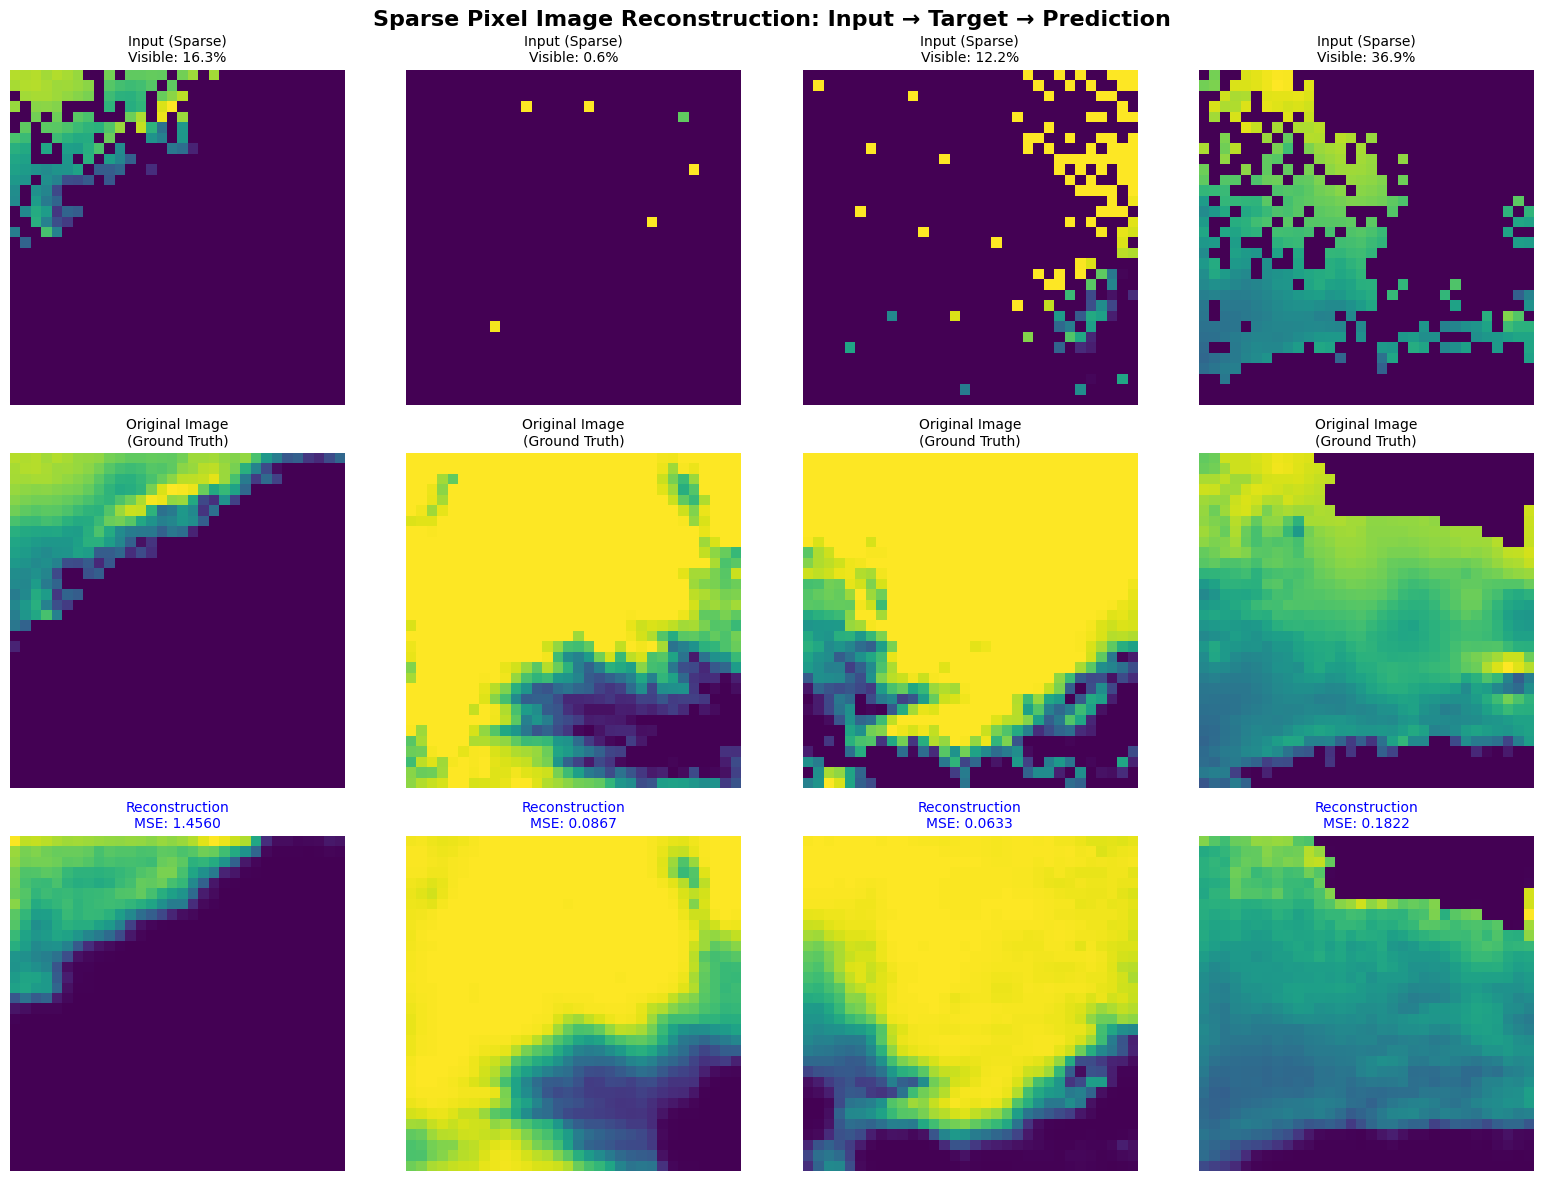

In [53]:
# Show sample sparse pixel reconstructions with original images
def show_sparse_reconstructions(model, dataset, num_samples=8):
    """Show model reconstructions comparing sparse input → original → prediction."""
    
    model.eval()
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    
    # Create a clean CIFAR-10 dataset to get original images
    import torchvision.datasets as datasets
    
    # Load original CIFAR-10 test dataset (without any transforms except tensor conversion)
    original_transform = transforms.Compose([transforms.ToTensor()])
    original_dataset = StationPatchDataset(
        dataarray=da_test,
        input_sparsity=1, #input_sparsity,
        output_sparsity=1, #output_sparsity,
        transform=transform, 
        )#datasets.CIFAR10(root='./data', train=False, transform=original_transform, download=False)
    
    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            # Get sparse data from our dataset
            sparse_input, sparse_target, input_mask, output_mask = dataset[idx]
            
            # Get original clean image
            original_image, _, _, _ = original_dataset[idx]
            
            # Get prediction
            sparse_input_batch = sparse_input.unsqueeze(0).to(device)
            predicted_image = model(sparse_input_batch).squeeze(0).cpu()
            
            # Convert tensors for display
            sparse_input_np = sparse_input[0].numpy() #.permute(1, 2, 0).numpy()
            original_np = original_image[0].numpy() #.permute(1, 2, 0).numpy()
            predicted_np = predicted_image.permute(1, 2, 0).numpy()
            
            # Clamp values to [0,1] for display
            sparse_input_np = np.clip(sparse_input_np, 0, 1)
            original_np = np.clip(original_np, 0, 1)
            predicted_np = np.clip(predicted_np, 0, 1)
            
            # Display in rows: sparse input, original, prediction
            col = i % 4
            
            # Row 0: Sparse input
            axes[0, col].imshow(sparse_input_np)
            axes[0, col].set_title(f'Input (Sparse)\nVisible: {input_mask.float().mean()*100:.1f}%', 
                                  fontsize=10)
            axes[0, col].axis('off')
            
            # Row 1: Original image (ground truth)
            axes[1, col].imshow(original_np)
            axes[1, col].set_title('Original Image\n(Ground Truth)', fontsize=10)
            axes[1, col].axis('off')
            
            # Row 2: Prediction  
            axes[2, col].imshow(predicted_np)
            
            # Calculate MSE between prediction and original
            mse = F.mse_loss(predicted_image, original_image[0].unsqueeze(0)).item()
            axes[2, col].set_title(f'Reconstruction\nMSE: {mse:.4f}', 
                                  fontsize=10, color='blue')
            axes[2, col].axis('off')
    
    # Set row labels
    axes[0, 0].set_ylabel('Sparse Input', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Original Image', fontsize=12, fontweight='bold')  
    axes[2, 0].set_ylabel('Reconstruction', fontsize=12, fontweight='bold')
    
    plt.suptitle('Sparse Pixel Image Reconstruction: Input → Target → Prediction', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sparse_reconstructions(model, test_dataset, num_samples=8)